## Rede Neural Artificial - I

### Importações

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

### Carregamento do banco de dados e Feature Engineering

In [2]:
base = pd.read_excel('BANCO_DE_DADOS.xlsx', sheet_name='Planilha1')

### Dividindo e normalizando os dados

In [3]:
X = base.drop(columns=['Divisor'])
y = base["Divisor"]

# Winsorization leve para tratar outliers
y = np.clip(y, y.quantile(0.05), y.quantile(0.95))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Criando a rede neural

In [4]:
def rede_neural_divisor(input_dim):
    model = keras.Sequential([
        # 1ª camada
        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001),
        input_shape=(input_dim,)),
        layers.BatchNormalization(),

        # Camada intermediária
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),

        # Camada intermediária
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),

        # Camada intermediária
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(1)])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae'])
    return model

model = rede_neural_divisor(X_train_sc.shape[1])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True)

history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_test_sc, y_test),
    epochs=500,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0)

### Salvando o modelo e o scaler

In [5]:
# Cria diretório para salvar o modelo
os.makedirs("modelo_rede_neural_divisor", exist_ok=True)

# Salva o modelo completo (arquitetura + pesos + estado do otimizador)
model.save("modelo_rede_neural_divisor/modelo_completo.keras")
print("\nModelo salvo em: modelo_rede_neural_divisor/modelo_completo.keras")

# Salva o scaler
joblib.dump(scaler, "modelo_rede_neural_divisor/scaler.pkl")
print("Scaler salvo em: modelo_rede_neural_divisor/scaler.pkl")


Modelo salvo em: modelo_rede_neural_divisor/modelo_completo.keras
Scaler salvo em: modelo_rede_neural_divisor/scaler.pkl


### Avaliando o modelo

In [6]:
y_pred = model.predict(X_test_sc).flatten()
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n=== RESULTADOS DA REDE NEURAL ===")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=== RESULTADOS DA REDE NEURAL ===
R²: 0.5983
RMSE: 28.5308
MAE: 20.2437


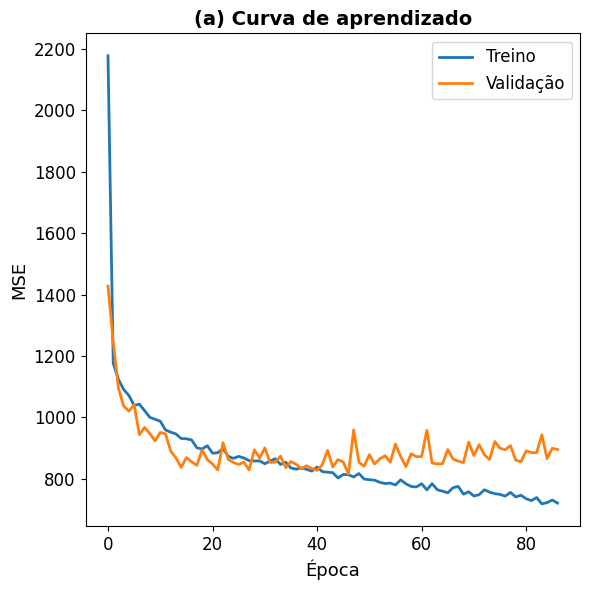

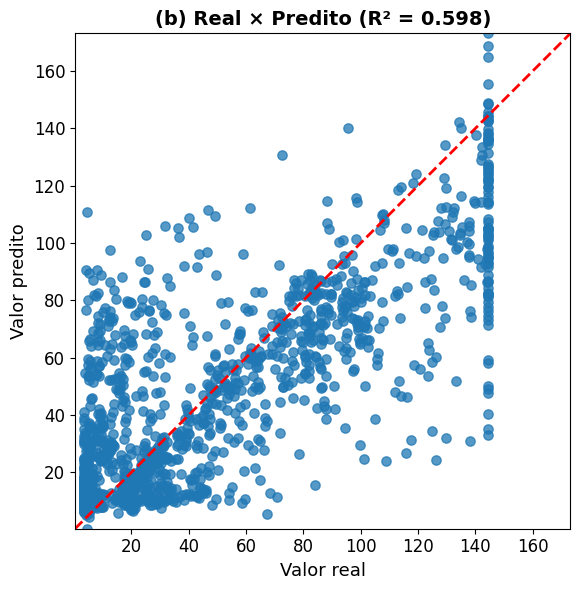

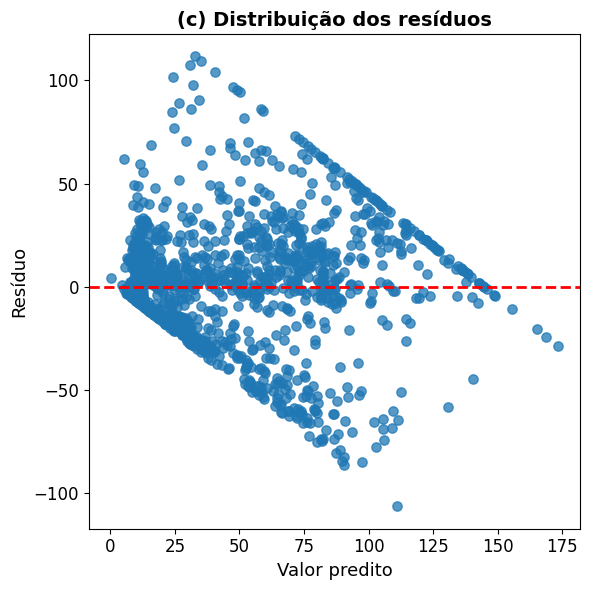

In [23]:
# ================================================================
# GRÁFICOS
# ================================================================

FIGSIZE = (6, 6)

TITLE_SIZE = 14
LABEL_SIZE = 13
TICK_SIZE = 12
LEGEND_SIZE = 12

# Curva de aprendizado
plt.figure(figsize=(6, 6))

plt.plot(history.history["loss"],
         linewidth=2.0,
         label="Treino")

plt.plot(history.history["val_loss"],
         linewidth=2.0,
         label="Validação")

plt.title("(a) Curva de aprendizado",
          fontsize=TITLE_SIZE,
          fontweight="bold")

plt.xlabel("Época", fontsize=LABEL_SIZE)
plt.ylabel("MSE", fontsize=LABEL_SIZE)

plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)

plt.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.show()

# Real vs Predito
plt.figure(figsize=(6, 6))

plt.scatter(y_test,
            y_pred,
            s=45,
            alpha=0.75)

lim = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(lim,
         lim,
         'r--',
         linewidth=2)

plt.title(f"(b) Real × Predito (R² = {r2:.3f})",
          fontsize=TITLE_SIZE,
          fontweight="bold")

plt.xlabel("Valor real", fontsize=LABEL_SIZE)
plt.ylabel("Valor predito", fontsize=LABEL_SIZE)

plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)

plt.xlim(lim)
plt.ylim(lim)

plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Resíduos
plt.figure(figsize=(6, 6))

plt.scatter(y_pred,
            y_test - y_pred,
            s=45,
            alpha=0.75)

plt.axhline(0,
            color='red',
            linestyle='--',
            linewidth=2)

plt.title("(c) Distribuição dos resíduos",
          fontsize=TITLE_SIZE,
          fontweight="bold")

plt.xlabel("Valor predito", fontsize=LABEL_SIZE)
plt.ylabel("Resíduo", fontsize=LABEL_SIZE)

plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)

plt.tight_layout()
plt.show()

### Usando o modelo salvo

In [8]:
# Para usar o modelo salvo em outro script
modelo_carregado = keras.models.load_model("modelo_rede_neural_divisor/modelo_completo.keras")
scaler_carregado = joblib.load("modelo_rede_neural_divisor/scaler.pkl")

### Função para previsão da rigidez a partir da Rede Neural

In [19]:
def prever_divisor(base, model, scaler):
    base = base.copy()

    dados_finais = base

    # Normalizar
    dados_normalizados = scaler.transform(dados_finais)

    # Prever
    pred = model.predict(dados_normalizados).flatten()

    return pred

### Dados de entrada

In [25]:
dados_usuario = pd.DataFrame([{
    "b (m)": 0.6,
    "h (m)": 1.48,
    "CAA": 2,
    "βt": 0.35,
    "βv": 0.45}])

### Resultado da rede neural

In [26]:
# Prever usando o modelo novo
resultado = prever_divisor(dados_usuario, model=modelo_carregado, scaler=scaler_carregado)

print(f"Divisor previsto = {resultado[0]:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Divisor previsto = 65.968
